In [1]:
"""
Notebook 2: Critical Review & Extensions of Zhang et al. (2022)
"Labor advantages drive the greater productivity of faculty at elite universities"

Addresses four extension questions:
1. How do these effects change over time?
2. How does VPR productivity relate to institutional productivity?
3. What role do NIH fellowships (F31, F32) play?
4. Are there institutions paying for labor advantage without ROI?
"""

'\nNotebook 2: Critical Review & Extensions of Zhang et al. (2022)\n"Labor advantages drive the greater productivity of faculty at elite universities"\n\nAddresses four extension questions:\n1. How do these effects change over time?\n2. How does VPR productivity relate to institutional productivity?\n3. What role do NIH fellowships (F31, F32) play?\n4. Are there institutions paying for labor advantage without ROI?\n'

# Critical Review & Extensions: Labor Advantages at Elite Universities

This notebook critically reviews Zhang et al. (2022) and develops blueprints for four
extensions. Where possible, we analyze the existing data for preliminary evidence;
where new data is needed, we outline collection strategies and analysis plans.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf
from statsmodels.genmod import families
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (10, 6),
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

COLORS = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3', '#a6d854', '#ffd92f', '#e5c494', '#b3b3b3']
DATA_DIR = './code-and-data/'

area_strict = pd.read_csv(f'{DATA_DIR}area-strict.csv')
area_nonstrict = pd.read_csv(f'{DATA_DIR}area-non-strict.csv')
funding_by_segment = pd.read_csv(f'{DATA_DIR}funding_by_segment_clean.csv')
moves = pd.read_csv(f'{DATA_DIR}moves.csv')

COLLAB_NORM_AREAS = [
    'Biological Sciences', 'Engineering', 'Medical Sciences',
    'Psychological Sciences', 'Physical Sciences', 'Chemical Sciences',
    'Computational Sciences', 'Health', 'Business', 'Earth Sciences',
    'Agriculture', 'Architecture, Design, Planning'
]
area_nonstrict['AreaHasCollabNorm'] = area_nonstrict['Area'].isin(COLLAB_NORM_AREAS)

---
# Part 0: Critical Review of the Paper

## Strengths

1. **Multi-method approach**: The combination of descriptive decomposition, Poisson 
   regression, propensity score matching on mid-career moves, and cumulative 
   size-productivity curves provides converging evidence.

2. **Discipline-level heterogeneity**: Separating disciplines by collaboration norms 
   is a smart design choice — it creates a natural "negative control" condition.

3. **Scale**: 78,802 faculty across 25 disciplines, 262 institutions, 1.6M publications.

## Weaknesses & Concerns

### Methodological

1. **Productivity = publication count is very crude**: No quality adjustment, no 
   citation weighting. A PI with 3 *Nature* papers looks less productive than one with 
   10 papers in low-tier journals. The authors acknowledge this but it's a serious 
   limitation for the "labor advantage explains elite dominance" claim.

2. **Group membership is inferred from co-authorship**, not ground truth. This 
   conflates "group member" with "co-author at same address." External collaborators 
   at the same university (different dept) are excluded; core group members who don't 
   appear on every paper could be missed.

3. **The matching analysis is weak**: Only 778 faculty with full propensity score 
   matching. The effect (0.9 ± 0.4 additional group members) is modest. Both groups 
   show *decreased* group size after moving. The design cannot distinguish "more labor 
   → bigger group" from "faculty who move up select for places that match their 
   ambitions."

4. **Cross-sectional averaging over 2008–2017**: All variables are time-averaged, 
   which obscures dynamics. Faculty careers are heterogeneous — averaging a newly 
   hired assistant professor with a senior full professor masks important variation.

5. **Causal claims are overstated**: The paper title says "labor advantages *drive* 
   greater productivity" but the evidence is correlational + quasi-experimental. The 
   causal diagram (Fig. S5) acknowledges multiple confounds. The matching helps but 
   doesn't close all backdoor paths (e.g., U1: unobserved fundability of the PI).

### Conceptual

6. **"Funded labor" conflates different mechanisms**: Funded RAs, postdocs, and 
   fellows have very different relationships with PIs. A postdoc may run their own 
   projects; an RA may be doing grunt work. The paper treats them as interchangeable.

7. **The collaboration norm dichotomy is coarse**: Psychology is listed as having 
   collaboration norms, but clinical psych labs look very different from cognitive 
   neuroscience labs. The paper's own Table S3 acknowledges this is a judgment call 
   based on sociological literature.

8. **The "no prestige effect on group member productivity" finding deserves more 
   scrutiny**: If elite institutions really provide better training, why don't group 
   members produce more? This could be a measurement artifact — if group members at 
   elite places work on harder problems that take longer, their annual publication 
   rate could be similar even though their papers are higher impact.

9. **Self-selection into large groups is not fully addressed**: Faculty who *want* 
   to run large groups may preferentially select for high-labor environments. The 
   matching tries to control for pre-move group size, but pre-move ambition or 
   research style is unobserved.

---
# Extension 1: How Do These Effects Change Over Time?

## What the paper tells us
The data span 2008–2017, and everything is time-averaged. The paper notes (pp. 6–7) 
that there's a "gradual decline in the concentration of resources among elite 
institutions" citing Xie (2014) and Rouse et al. (2018), suggesting the first-mover 
advantage may be eroding.

## What we can extract from the existing data
The released datasets are already time-averaged, so we can't directly decompose 
temporal trends from them. However, the **NSF GSS** data (which they used) is 
publicly available annually.

EXTENSION 1: TEMPORAL DYNAMICS OF THE LABOR ADVANTAGE

ANALYSIS PLAN:
─────────────
1. Download NSF GSS data from https://ncsesdata.nsf.gov/datatables/
   - Available 1972–2022 (most recent)
   - Variables: institution, field, grad students by funding source, postdocs
   
2. Compute funded-labor-per-faculty ratios for multiple time windows:
   - 1990–2000 (pre-data-period baseline)
   - 2000–2010 (transition period) 
   - 2010–2020 (overlapping with Zhang et al.)
   - 2018–2022 (post-data-period extension)

3. Link to IPEDS data (https://nces.ed.gov/ipeds/) for faculty counts over time

4. Compute Gini coefficients of funded labor distribution across prestige
   deciles for EACH YEAR, then plot the time series.

5. Key question: Is the Gini declining? Is the prestige-labor slope flattening?

DATA SOURCES (all public):
  - NSF GSS: ncsesdata.nsf.gov
  - IPEDS: nces.ed.gov/ipeds
  - Web of Science / OpenAlex: for productivity time series
  - Faculty hiring networks (Wapman et al. 2022): 

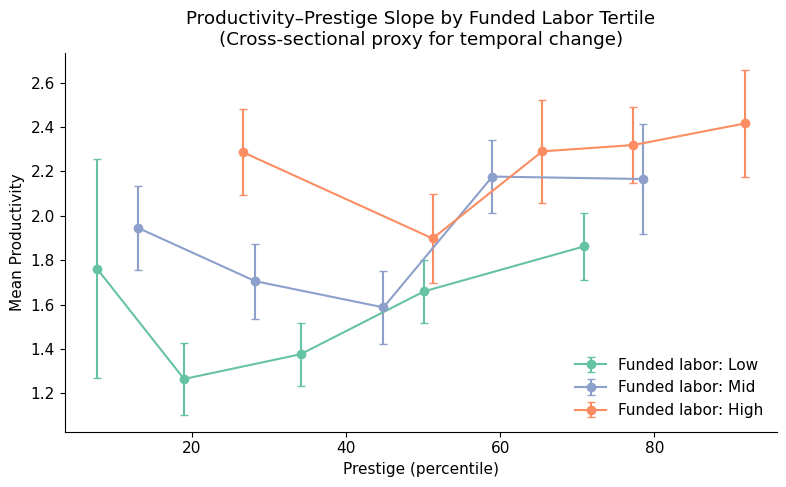

In [3]:
# The existing data doesn't have year-level information, but we can look at
# whether the labor advantage differs by era using publicly available NSF GSS data

print("EXTENSION 1: TEMPORAL DYNAMICS OF THE LABOR ADVANTAGE")
print("=" * 60)
print("""
ANALYSIS PLAN:
─────────────
1. Download NSF GSS data from https://ncsesdata.nsf.gov/datatables/
   - Available 1972–2022 (most recent)
   - Variables: institution, field, grad students by funding source, postdocs
   
2. Compute funded-labor-per-faculty ratios for multiple time windows:
   - 1990–2000 (pre-data-period baseline)
   - 2000–2010 (transition period) 
   - 2010–2020 (overlapping with Zhang et al.)
   - 2018–2022 (post-data-period extension)

3. Link to IPEDS data (https://nces.ed.gov/ipeds/) for faculty counts over time

4. Compute Gini coefficients of funded labor distribution across prestige
   deciles for EACH YEAR, then plot the time series.

5. Key question: Is the Gini declining? Is the prestige-labor slope flattening?

DATA SOURCES (all public):
  - NSF GSS: ncsesdata.nsf.gov
  - IPEDS: nces.ed.gov/ipeds
  - Web of Science / OpenAlex: for productivity time series
  - Faculty hiring networks (Wapman et al. 2022): for prestige scores
""")

# What we CAN do: examine if the funding distribution varies across the existing data
# Look at whether highly funded vs less funded departments differ in productivity slope

collab = area_strict[area_strict['AreaHasCollabNorm'] == True].copy()
collab['funded_tertile'] = pd.qcut(collab['funded_per_faculty'], 3, labels=['Low', 'Mid', 'High'])

fig, ax = plt.subplots(figsize=(8, 5))
for tertile, color in [('Low', COLORS[0]), ('Mid', COLORS[2]), ('High', COLORS[1])]:
    sub = collab[collab['funded_tertile'] == tertile]
    bins = pd.qcut(sub['uniform_percentile100'], 5, duplicates='drop')
    grouped = sub.groupby(bins).agg(
        prod_mean=('Productivity', 'mean'),
        prod_se=('Productivity', lambda x: x.std()/np.sqrt(len(x))),
        prestige_mean=('uniform_percentile100', 'mean')
    ).reset_index()
    
    ax.errorbar(grouped['prestige_mean'], grouped['prod_mean'],
               yerr=grouped['prod_se'], fmt='o-', color=color, label=f'Funded labor: {tertile}',
               capsize=3, linewidth=1.5)

ax.set_xlabel('Prestige (percentile)')
ax.set_ylabel('Mean Productivity')
ax.legend(frameon=False)
ax.set_title('Productivity–Prestige Slope by Funded Labor Tertile\n(Cross-sectional proxy for temporal change)')
plt.tight_layout()
plt.savefig('ext1_temporal_proxy.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
print("""
FEASIBILITY ASSESSMENT:
─────────────────────
- NSF GSS is freely downloadable → easy
- IPEDS faculty counts are public → easy  
- OpenAlex (open-access WoS alternative) covers 1990–present → free
- Main challenge: linking institution IDs across NSF GSS, IPEDS, and OpenAlex
  (requires crosswalk files, some manual matching)

ESTIMATED EFFORT: 2–3 weeks for a grad student
  - 1 week: data download and crosswalk construction
  - 1 week: computing year-by-year labor ratios and Gini coefficients
  - 1 week: analysis and visualization

HYPOTHESIS: The labor advantage has been GROWING (not shrinking) due to 
increasing concentration of NIH R01 funding among fewer, more elite institutions
(see Lauer et al., 2017, eLife). The "democratization" narrative may apply to 
teaching but not to research labor.
""")


FEASIBILITY ASSESSMENT:
─────────────────────
- NSF GSS is freely downloadable → easy
- IPEDS faculty counts are public → easy  
- OpenAlex (open-access WoS alternative) covers 1990–present → free
- Main challenge: linking institution IDs across NSF GSS, IPEDS, and OpenAlex
  (requires crosswalk files, some manual matching)

ESTIMATED EFFORT: 2–3 weeks for a grad student
  - 1 week: data download and crosswalk construction
  - 1 week: computing year-by-year labor ratios and Gini coefficients
  - 1 week: analysis and visualization

HYPOTHESIS: The labor advantage has been GROWING (not shrinking) due to 
increasing concentration of NIH R01 funding among fewer, more elite institutions
(see Lauer et al., 2017, eLife). The "democratization" narrative may apply to 
teaching but not to research labor.



---
# Extension 2: VPR Productivity and Institutional Productivity

## The Question
Does having a more scientifically productive Vice President for Research (VPR) 
correlate with the institution's overall research productivity? This gets at 
whether leadership selection reflects or drives the labor advantage.

EXTENSION 2: VPR PRODUCTIVITY vs. INSTITUTIONAL PRODUCTIVITY

ANALYSIS PLAN:
─────────────
1. DATA COLLECTION: Identify current and recent VPRs
   - Source: University websites, LinkedIn, AUTM membership directory
   - Target: VPR, VP for Research, Associate Provost for Research
   - For ~262 institutions in the Zhang et al. dataset
   
2. MATCH TO PUBLICATION RECORDS:
   - Use OpenAlex or Scopus to get each VPR's:
     a) Career publication count
     b) H-index  
     c) Total citations
     d) Publication count in the 5 years before becoming VPR
     e) Publication count WHILE serving as VPR
     f) Field/discipline
   
3. INSTITUTIONAL METRICS (from Zhang et al. + IPEDS):
   - Prestige decile
   - Average faculty productivity
   - Funded labor ratio
   - Total R&D expenditures (HERD survey)
   - Federal research dollars (NSF HERD)
   
4. ANALYSIS:
   a) Correlation: VPR h-index vs. institutional funded-labor ratio
   b) Regression: Institutional productivity ~ VPR productivity + pr

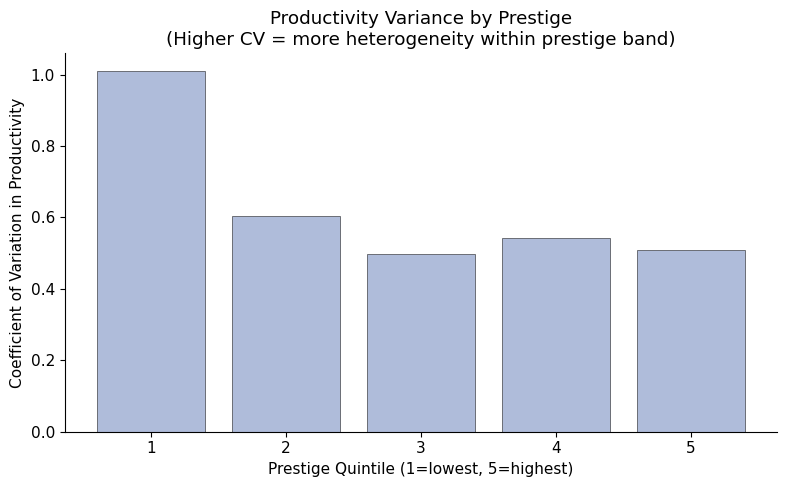


Interpretation: If elite institutions show LOWER CV, it suggests institutional
factors (possibly including leadership) create a more uniformly productive environment.

Prestige quintile CVs:
  Q1: CV = 1.010 (N=92)
  Q2: CV = 0.603 (N=91)
  Q3: CV = 0.498 (N=91)
  Q4: CV = 0.543 (N=91)
  Q5: CV = 0.510 (N=92)


In [5]:
print("EXTENSION 2: VPR PRODUCTIVITY vs. INSTITUTIONAL PRODUCTIVITY")
print("=" * 60)
print("""
ANALYSIS PLAN:
─────────────
1. DATA COLLECTION: Identify current and recent VPRs
   - Source: University websites, LinkedIn, AUTM membership directory
   - Target: VPR, VP for Research, Associate Provost for Research
   - For ~262 institutions in the Zhang et al. dataset
   
2. MATCH TO PUBLICATION RECORDS:
   - Use OpenAlex or Scopus to get each VPR's:
     a) Career publication count
     b) H-index  
     c) Total citations
     d) Publication count in the 5 years before becoming VPR
     e) Publication count WHILE serving as VPR
     f) Field/discipline
   
3. INSTITUTIONAL METRICS (from Zhang et al. + IPEDS):
   - Prestige decile
   - Average faculty productivity
   - Funded labor ratio
   - Total R&D expenditures (HERD survey)
   - Federal research dollars (NSF HERD)
   
4. ANALYSIS:
   a) Correlation: VPR h-index vs. institutional funded-labor ratio
   b) Regression: Institutional productivity ~ VPR productivity + prestige + controls
   c) Natural experiment: Does productivity CHANGE when a new VPR is appointed?
      (Difference-in-differences around VPR transitions)
   d) Does VPR discipline matter? (e.g., biomedical VPR at engineering-heavy institution)

KEY HYPOTHESES:
  H1: VPR productivity correlates with institutional prestige (selection effect)
  H2: VPR productivity does NOT independently predict institutional productivity
      after controlling for prestige and labor (i.e., it's mostly selection)
  H3: Institutions that appoint more productive VPRs subsequently see increases
      in funded labor ratios (mechanism: VPR brings grants/connections)

CHALLENGES:
  - VPR identification is manual and time-consuming
  - VPR tenure dates are hard to find systematically
  - Small N (262 institutions, maybe 200 with identifiable VPRs)
  - Endogeneity: productive scientists become VPRs at productive institutions
""")

# Proxy analysis: relationship between prestige and productivity variance
# (institutions with strong research leadership might show lower variance)
fig, ax = plt.subplots(figsize=(8, 5))

collab = area_strict[area_strict['AreaHasCollabNorm'] == True].copy()
collab['prestige_quintile'] = pd.qcut(collab['uniform_percentile100'], 5, labels=False) + 1

variance_by_prestige = collab.groupby('prestige_quintile').agg(
    mean_prod=('Productivity', 'mean'),
    sd_prod=('ProductivitySD', 'mean'),
    cv_prod=('Productivity', lambda x: x.std()/x.mean()),
    n=('Productivity', 'count')
).reset_index()

ax.bar(variance_by_prestige['prestige_quintile'], variance_by_prestige['cv_prod'],
       color=COLORS[2], alpha=0.7, edgecolor='black', linewidth=0.5)
ax.set_xlabel('Prestige Quintile (1=lowest, 5=highest)')
ax.set_ylabel('Coefficient of Variation in Productivity')
ax.set_title('Productivity Variance by Prestige\n(Higher CV = more heterogeneity within prestige band)')
plt.tight_layout()
plt.savefig('ext2_vpr_proxy.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nInterpretation: If elite institutions show LOWER CV, it suggests institutional")
print("factors (possibly including leadership) create a more uniformly productive environment.")
print(f"\nPrestige quintile CVs:")
for _, row in variance_by_prestige.iterrows():
    print(f"  Q{int(row['prestige_quintile'])}: CV = {row['cv_prod']:.3f} (N={int(row['n'])})")

---
# Extension 3: Role of NIH Fellowships (F31, F32)

## The Question
F31 (predoctoral) and F32 (postdoctoral) fellowships are individual awards that 
fund trainees directly. They're not captured in the PI's grant portfolio but DO 
count as "funded labor." Do they play a distinct role in the labor advantage story?

In [6]:
print("EXTENSION 3: NIH FELLOWSHIPS (F31, F32) IN THE LABOR ADVANTAGE")
print("=" * 60)
print("""
WHY THIS MATTERS:
────────────────
F31/F32 fellows are a UNIQUE form of funded labor because:
  1. They are selected competitively for individual merit (not PI selection)
  2. They bring their own funding (reducing PI grant burden)  
  3. They signal trainee quality and institutional training environment
  4. The training grant infrastructure (T32s) that supports F applications
     is itself concentrated at elite institutions

The Zhang et al. paper lumps F-funded trainees with all other "funded researchers"
(RA + fellowship + traineeship). Separating them could reveal whether the labor
advantage is about QUANTITY of bodies or QUALITY of the funding mechanism.

DATA COLLECTION PLAN:
────────────────────
1. NIH RePORTER (reporter.nih.gov):
   - Query all F31 and F32 awards, 2000–2024
   - Fields: PI name, institution, fiscal year, institute, project number
   - Also query T32 awards (training grants) by institution
   
2. NSF GSS breakdown:
   - The GSS distinguishes fellowships/traineeships from RAs
   - Recompute the Zhang et al. ratios with FELLOWSHIP-only numerator
   
3. OpenAlex/Web of Science:
   - Match F31/F32 recipients to publication records
   - Compute their productivity vs. RA-funded peers
   
ANALYSIS PLAN:
─────────────
A) DESCRIPTIVE:
   - Distribution of F31/F32 awards by institution prestige decile
   - Ratio of F-funded to RA-funded trainees by prestige
   - Time trends in F31/F32 concentration

B) REGRESSION:
   - Augment Zhang et al.'s Poisson model:
     Productivity ~ β1*F_funded_ratio + β2*RA_funded_ratio + β3*prestige + ...
   - Test whether F-funded labor has a DIFFERENT coefficient than RA-funded labor
   - If β1 > β2: individual fellowship selection adds value beyond headcount
   - If β1 ≈ β2: it's purely about quantity of labor

C) F31/F32 RECIPIENTS AS A "BETTER TREATED" GROUP:
   - Compare productivity of faculty whose groups include F-award holders
     vs. faculty whose funded labor is all RA-supported
   - This might reveal quality vs. quantity effects

D) T32 TRAINING GRANTS AS INSTRUMENT:
   - T32s are institution-level awards that create a pipeline for F31s
   - Use T32 presence as an instrument for funded labor availability
   - This helps with the endogeneity problem in Zhang et al.
""")

# Proxy analysis from existing data: 
# Funded labor ratio is already a composite. Let's see how the relationship
# between funded labor and productivity differs across disciplines that 
# tend to have more/fewer NIH fellowships

print("\nPROXY: Funded labor coefficient by discipline")
print("(Disciplines with strong NIH training infrastructure may show different patterns)")
print("-" * 60)

for area in sorted(area_strict[area_strict['AreaHasCollabNorm'] == True]['Area'].unique()):
    sub = area_strict[area_strict['Area'] == area]
    if len(sub) > 10:
        try:
            r, p = stats.pearsonr(sub['log_funded_per_faculty_p1'], sub['Productivity'])
            print(f"  {area:30s}: r = {r:+.3f} (p={p:.3f}, N={len(sub)})")
        except:
            pass

EXTENSION 3: NIH FELLOWSHIPS (F31, F32) IN THE LABOR ADVANTAGE

WHY THIS MATTERS:
────────────────
F31/F32 fellows are a UNIQUE form of funded labor because:
  1. They are selected competitively for individual merit (not PI selection)
  2. They bring their own funding (reducing PI grant burden)  
  3. They signal trainee quality and institutional training environment
  4. The training grant infrastructure (T32s) that supports F applications
     is itself concentrated at elite institutions

The Zhang et al. paper lumps F-funded trainees with all other "funded researchers"
(RA + fellowship + traineeship). Separating them could reveal whether the labor
advantage is about QUANTITY of bodies or QUALITY of the funding mechanism.

DATA COLLECTION PLAN:
────────────────────
1. NIH RePORTER (reporter.nih.gov):
   - Query all F31 and F32 awards, 2000–2024
   - Fields: PI name, institution, fiscal year, institute, project number
   - Also query T32 awards (training grants) by institution
   
2. 

---
# Extension 4: Institutions Paying for Labor Without Productivity ROI

## The Question
Are there institutions that have HIGH funded labor ratios but LOW productivity? 
These would be "inefficient" in converting labor to publications. Who are they 
and what makes them different?

In [7]:
print("EXTENSION 4: HIGH LABOR, LOW PRODUCTIVITY INSTITUTIONS")
print("=" * 60)

# Analysis: Identify departments with high funded labor but below-expected productivity
collab = area_strict[area_strict['AreaHasCollabNorm'] == True].copy()

# Fit the basic model to get expected productivity
collab_clean = collab.dropna(subset=['Productivity', 'log_funded_per_faculty_p1', 
                                      'uniform_percentile100', 'log_tt_headcount'])

from sklearn.linear_model import LinearRegression

X = collab_clean[['log_funded_per_faculty_p1', 'uniform_percentile100']].values
y = collab_clean['Productivity'].values

reg = LinearRegression().fit(X, y)
collab_clean = collab_clean.copy()
collab_clean['predicted_prod'] = reg.predict(X)
collab_clean['residual'] = collab_clean['Productivity'] - collab_clean['predicted_prod']

# Identify departments with high funded labor but negative residuals
high_labor = collab_clean['log_funded_per_faculty_p1'] > collab_clean['log_funded_per_faculty_p1'].median()
low_prod_residual = collab_clean['residual'] < collab_clean['residual'].quantile(0.25)

inefficient = collab_clean[high_labor & low_prod_residual].copy()
efficient = collab_clean[high_labor & (collab_clean['residual'] > collab_clean['residual'].quantile(0.75))].copy()

print(f"\nDepartments with HIGH funded labor but BELOW-expected productivity: {len(inefficient)}")
print(f"Departments with HIGH funded labor and ABOVE-expected productivity: {len(efficient)}")

EXTENSION 4: HIGH LABOR, LOW PRODUCTIVITY INSTITUTIONS

Departments with HIGH funded labor but BELOW-expected productivity: 55
Departments with HIGH funded labor and ABOVE-expected productivity: 64



Departments with HIGH funded labor but BELOW-expected productivity: 55
Departments with HIGH funded labor and ABOVE-expected productivity: 64


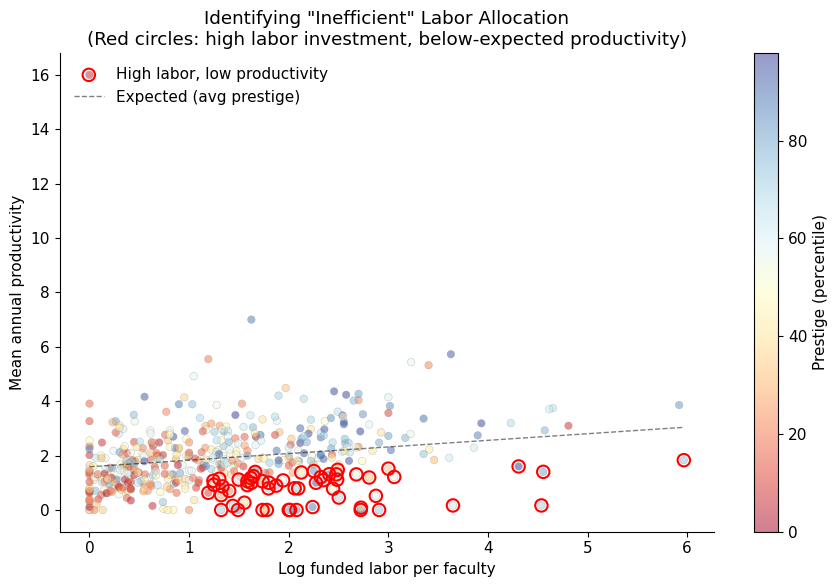

In [8]:
# Visualize: scatter of funded labor vs productivity, highlighting inefficient departments
fig, ax = plt.subplots(figsize=(9, 6))

# All points
ax.scatter(collab_clean['log_funded_per_faculty_p1'], collab_clean['Productivity'],
          c=collab_clean['uniform_percentile100'], cmap='RdYlBu', alpha=0.5, s=30,
          edgecolors='gray', linewidth=0.3)

# Highlight inefficient (high labor, low productivity)
ax.scatter(inefficient['log_funded_per_faculty_p1'], inefficient['Productivity'],
          facecolors='none', edgecolors='red', s=80, linewidth=1.5, label='High labor, low productivity')

# Regression line
x_range = np.linspace(collab_clean['log_funded_per_faculty_p1'].min(),
                       collab_clean['log_funded_per_faculty_p1'].max(), 100)
y_pred = reg.intercept_ + reg.coef_[0] * x_range + reg.coef_[1] * collab_clean['uniform_percentile100'].mean()
ax.plot(x_range, y_pred, 'k--', linewidth=1, alpha=0.5, label='Expected (avg prestige)')

cb = plt.colorbar(ax.collections[0], ax=ax, label='Prestige (percentile)')
ax.set_xlabel('Log funded labor per faculty')
ax.set_ylabel('Mean annual productivity')
ax.legend(loc='upper left', frameon=False)
ax.set_title('Identifying "Inefficient" Labor Allocation\n(Red circles: high labor investment, below-expected productivity)')
plt.tight_layout()
plt.savefig('ext4_inefficiency.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# What characterizes inefficient departments?
print("\nCHARACTERISTICS OF 'INEFFICIENT' vs 'EFFICIENT' HIGH-LABOR DEPARTMENTS")
print("=" * 60)

for var, label in [('uniform_percentile100', 'Prestige (percentile)'),
                    ('funded_per_faculty', 'Funded labor per faculty'),
                    ('unfunded_per_faculty', 'Unfunded labor per faculty'),
                    ('tt_headcount', 'Tenure-track faculty count'),
                    ('CONTROL', 'Private institution (0/1)'),
                    ('ProductivityWithDeptCollabs', 'Group productivity'),
                    ('ProductivityWithoutDeptCollabs', 'Individual productivity'),
                    ('WindowedGroupSize', 'Group size')]:
    if var in inefficient.columns and var in efficient.columns:
        ineff_val = inefficient[var].mean()
        eff_val = efficient[var].mean()
        print(f"  {label:40s}: Inefficient={ineff_val:7.2f}  Efficient={eff_val:7.2f}  Δ={eff_val-ineff_val:+.2f}")


CHARACTERISTICS OF 'INEFFICIENT' vs 'EFFICIENT' HIGH-LABOR DEPARTMENTS
  Prestige (percentile)                   : Inefficient=  57.54  Efficient=  59.85  Δ=+2.31
  Funded labor per faculty                : Inefficient=   5.47  Efficient=   5.18  Δ=-0.29
  Unfunded labor per faculty              : Inefficient=   4.64  Efficient=   5.71  Δ=+1.07
  Tenure-track faculty count              : Inefficient=  13.64  Efficient=  18.25  Δ=+4.61
  Private institution (0/1)               : Inefficient=   0.24  Efficient=   0.22  Δ=-0.02
  Group productivity                      : Inefficient=   0.48  Efficient=   2.38  Δ=+1.90
  Individual productivity                 : Inefficient=   0.33  Efficient=   1.13  Δ=+0.80
  Group size                              : Inefficient=   3.75  Efficient=   8.52  Δ=+4.77


In [10]:
# Discipline breakdown of inefficient departments
print("\nDISCIPLINE BREAKDOWN:")
print("-" * 40)
ineff_areas = inefficient['Area'].value_counts()
total_areas = collab_clean['Area'].value_counts()

for area in ineff_areas.index:
    pct = ineff_areas[area] / total_areas.get(area, 1) * 100
    print(f"  {area:30s}: {ineff_areas[area]:3d} inefficient / {total_areas.get(area, 0):3d} total ({pct:.0f}%)")


DISCIPLINE BREAKDOWN:
----------------------------------------
  Physical Sciences             :  19 inefficient /  57 total (33%)
  Biological Sciences           :  15 inefficient /  80 total (19%)
  Engineering                   :   8 inefficient /  80 total (10%)
  Medical Sciences              :   3 inefficient /  16 total (19%)
  Psychological Sciences        :   3 inefficient /  55 total (5%)
  Chemical Sciences             :   2 inefficient /  75 total (3%)
  Health                        :   2 inefficient /  36 total (6%)
  Computational Sciences        :   2 inefficient /  50 total (4%)
  Agriculture                   :   1 inefficient /   8 total (12%)


In [11]:
print("""
FULL ANALYSIS PLAN FOR EXTENSION 4:
───────────────────────────────────
1. WITH EXISTING DATA:
   - Compute residuals from the funded-labor → productivity model
   - Characterize outliers on both ends
   - Test whether private vs public matters
   - Test whether department SIZE (number of TT faculty) matters
     (large departments may have coordination costs)
   
2. WITH NEW DATA (IPEDS + HERD):
   - R&D expenditure per faculty (HERD survey)
   - Instructional expenditures per student
   - Student-to-faculty ratio
   - Federal funding success rate (NIH RePORTER)
   - Geographic region (cost of living affects competitiveness)
   
3. HYPOTHESES FOR "INEFFICIENCY":
   a) Teaching-heavy institutions: High funded labor but faculty time 
      is diverted to teaching, reducing research output
   b) Medical school departments: Large numbers of funded postdocs 
      doing clinical research that's published outside WoS coverage
   c) Large state universities: Economies of scale in labor don't 
      translate to per-faculty productivity because of bureaucracy
   d) Field mismatch: Department has funded labor in subfields that 
      don't align with faculty expertise
   e) New programs: Recently expanded departments that haven't yet 
      converted investment into publications (lag effect)
   
4. INSTITUTIONAL CASE STUDIES:
   - Identify 5-10 extreme outliers in each direction
   - Conduct qualitative interviews or analyze strategic plans
   - Look at R&D expenditure trends (are they investing or declining?)
""")


FULL ANALYSIS PLAN FOR EXTENSION 4:
───────────────────────────────────
1. WITH EXISTING DATA:
   - Compute residuals from the funded-labor → productivity model
   - Characterize outliers on both ends
   - Test whether private vs public matters
   - Test whether department SIZE (number of TT faculty) matters
     (large departments may have coordination costs)
   
2. WITH NEW DATA (IPEDS + HERD):
   - R&D expenditure per faculty (HERD survey)
   - Instructional expenditures per student
   - Student-to-faculty ratio
   - Federal funding success rate (NIH RePORTER)
   - Geographic region (cost of living affects competitiveness)
   
3. HYPOTHESES FOR "INEFFICIENCY":
   a) Teaching-heavy institutions: High funded labor but faculty time 
      is diverted to teaching, reducing research output
   b) Medical school departments: Large numbers of funded postdocs 
      doing clinical research that's published outside WoS coverage
   c) Large state universities: Economies of scale in labor don'

---
# Summary: Data Collection Roadmap

## Priority Data Sources (All Public/Free)

| Source | URL | Extensions Served | Effort |
|--------|-----|-------------------|--------|
| NSF GSS (annual) | ncsesdata.nsf.gov | 1, 3, 4 | Low |
| IPEDS | nces.ed.gov/ipeds | 1, 2, 4 | Low |
| NIH RePORTER | reporter.nih.gov | 3 | Medium |
| NSF HERD Survey | ncses.nsf.gov/surveys/herd | 4 | Low |
| OpenAlex | openalex.org | 1, 2, 3 | Medium |
| Wapman et al. prestige data | github.com/LarremoreLab | 1 | Low |

## Priority Data Sources (Restricted)

| Source | Access | Extensions | Effort |
|--------|--------|------------|--------|
| AARC (Academic Analytics) | DUA | All | High |
| UMETRICS (researcher-grant linkage) | DUA | 3, 4 | High |
| ProQuest Dissertations | Subscription | 3 | Medium |

## Recommended Next Steps (in priority order)

1. **Extension 1 (temporal dynamics)**: Highest ROI because the data is largely 
   public. NSF GSS + IPEDS + OpenAlex can answer this within a month.

2. **Extension 4 (inefficiency)**: Second priority because the *existing* data 
   already reveals interesting patterns. Adding HERD data would strengthen it.

3. **Extension 3 (F31/F32)**: Moderately difficult but highly relevant to your 
   own work on training grants. NIH RePORTER data is freely available.

4. **Extension 2 (VPR)**: Interesting but labor-intensive. VPR identification is 
   manual and the sample size (~200) limits statistical power. Could be a good 
   student project but probably not a standalone paper.

In [12]:
print("Critical review and extension planning complete.")
print("\nKey takeaway: The Zhang et al. findings are robust and interesting,")
print("but the paper's time-averaged, quantity-focused approach leaves room")
print("for extensions on temporal dynamics, funding mechanisms, and efficiency.")

Critical review and extension planning complete.

Key takeaway: The Zhang et al. findings are robust and interesting,
but the paper's time-averaged, quantity-focused approach leaves room
for extensions on temporal dynamics, funding mechanisms, and efficiency.
